<a href="https://colab.research.google.com/github/MateusA-Borges/rainfall-prediction-project-senac-UC9/blob/main/ProjetoRainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/train R.csv')
test = pd.read_csv('/content/drive/MyDrive/test R.csv')

In [ ]:
test.isnull().sum()

,0
id,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0


In [ ]:
train = train.drop(["id"], axis=1)

In [ ]:
test_ids = test["id"]
test = test.drop("id", axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = train.drop(["rainfall"], axis=1)
y = train['rainfall']
X_test = test

mean_winddirection = X['winddirection'].mean()
# Fill the missing value in the test data with the calculated mean
test['winddirection'].fillna(mean_winddirection, inplace=True)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(test)

print("Data scaled successfully.")

Data scaled successfully.


/tmp/ipython-input-3486530257.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['winddirection'].fillna(mean_winddirection, inplace=True)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Feature: 0, Score: 0.00037
Feature: 1, Score: -0.00845
Feature: 2, Score: -0.00441
Feature: 3, Score: -0.00633
Feature: 4, Score: -0.00512
Feature: 5, Score: 0.10967
Feature: 6, Score: 0.04524
Feature: 7, Score: 0.06412
Feature: 8, Score: -0.15837
Feature: 9, Score: -0.00009
Feature: 10, Score: 0.01451


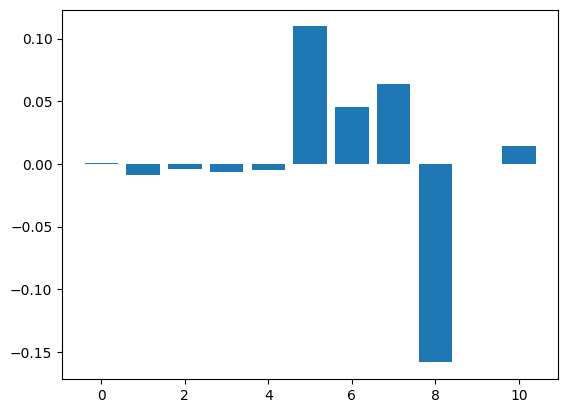

In [ ]:
# fazer o drop `id` do dataset train, ja que nao é necessario
#train_df = train_df.drop(["id", "day"], axis=1)

# separar X and y
X_train = train.drop(["rainfall"], axis=1)
y_train = train["rainfall"]

# logistic regression para importancia das features
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
# definir o modelo
model = LogisticRegression()
# fitar o model
model.fit(X_train, y_train)
# descobrir importancia
importance = model.coef_[0]
# sumarizar importancia das features
for i,v in enumerate(importance):
        print('Feature: %0d, Score: %.5f' % (i,v))
# plotar importancia das features
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()


Evaluation with HistGradientBoostingClassifier on Validation Set (before PCA):
Accuracy: 0.8584474885844748

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68       162
           1       0.88      0.94      0.91       495

    accuracy                           0.86       657
   macro avg       0.82      0.78      0.80       657
weighted avg       0.85      0.86      0.85       657


Confusion Matrix:


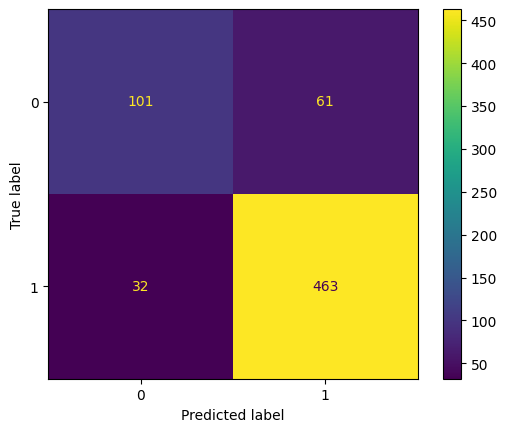

AUC on Validation Set (HistGradientBoostingClassifier before PCA): 0.867813941888016
Model classes: [0 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# Split scaled data into training and validation sets for evaluation
X_train_eval_scaled, X_test_eval_scaled, y_train_eval, y_test_eval = train_test_split(X_train_scaled, y, test_size=0.3, random_state=42, stratify=y)


# Create a HistGradientBoostingClassifier model
hist_gbm = HistGradientBoostingClassifier(random_state=42)

# Train the model on the scaled training data
hist_gbm.fit(X_train_eval_scaled, y_train_eval)

# Evaluate the model on the scaled validation set
y_pred_eval_gbm = hist_gbm.predict(X_test_eval_scaled)
y_pred_proba_eval_gbm = hist_gbm.predict_proba(X_test_eval_scaled)[:, 1]

print("\nEvaluation with HistGradientBoostingClassifier on Validation Set (before PCA):")
print("Accuracy:", accuracy_score(y_test_eval, y_pred_eval_gbm))
print("\nClassification Report:")
print(classification_report(y_test_eval, y_pred_eval_gbm))
print("\nConfusion Matrix:")
cm_gbm = confusion_matrix(y_test_eval, y_pred_eval_gbm)
disp_gbm = ConfusionMatrixDisplay(confusion_matrix=cm_gbm)
disp_gbm.plot()
plt.show()

fpr_gbm, tpr_gbm, thresholds_gbm = roc_curve(y_test_eval, y_pred_proba_eval_gbm)
roc_auc_gbm = auc(fpr_gbm, tpr_gbm)
print("AUC on Validation Set (HistGradientBoostingClassifier):", roc_auc_gbm)

rainfall_prob_gbm = hist_gbm.predict_proba(X_test_scaled)[:, 1]

predictions = hist_gbm.predict_proba(X_test)

print(f"Model classes: {hist_gbm.classes_}")

predictions = predictions[: , 1] # Get probability at index 1 for all samples

submission = pd.DataFrame({'id': test_ids, 'rainfall': predictions})
#submission.to_csv("submission_gbm.csv", index=False)# DataFrame for submission

#submission_gbm = pd.DataFrame({
   # "id": test_ids,
   # "rainfall": rainfall_prob_gbm
#})
#print("\nSubmission DataFrame shape (HistGradientBoostingClassifier):", submission_gbm.shape)
#submission_gbm.to_csv('submission_hist_gbm.csv', index=False)
#print("Submission file created: submission_hist_gbm.csv")

# files.download("submission_hist_gbm.csv")

Confusion Matrix (on evaluation set):
[[109  58]
 [ 29 461]]

Classification Report (on evaluation set):
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       167
           1       0.89      0.94      0.91       490

    accuracy                           0.87       657
   macro avg       0.84      0.80      0.81       657
weighted avg       0.86      0.87      0.86       657



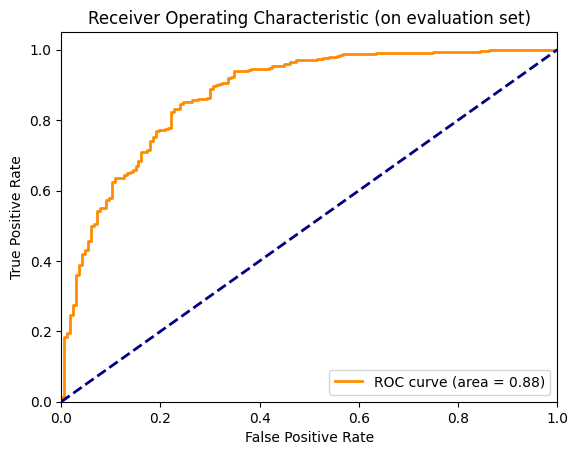

AUC (on evaluation set): 0.8750947085420995

Submission DataFrame shape: (730, 2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import pandas as pd


X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(X, y, test_size=0.3, random_state=42)


svm_model = SVC(kernel='linear', C=1, probability=True)


svm_model.fit(X_train_eval, y_train_eval)


y_pred_eval = svm_model.predict(X_test_eval)
y_pred_proba_eval = svm_model.predict_proba(X_test_eval)[:, 1]


print("Confusion Matrix (on evaluation set):")
print(confusion_matrix(y_test_eval, y_pred_eval))

print("\nClassification Report (on evaluation set):")
print(classification_report(y_test_eval, y_pred_eval))

fpr, tpr, thresholds = roc_curve(y_test_eval, y_pred_proba_eval)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (on evaluation set)')
plt.legend(loc="lower right")
plt.show()

print("AUC (on evaluation set):", roc_auc)

rainfall_prob = svm_model.predict_proba(test)[:, 1]

# DataFrame para submissão
submission = pd.DataFrame({
    "id": test_ids,
    "rainfall": rainfall_prob
})
print("\nSubmission DataFrame shape:", submission.shape)
#submission.to_csv('submission_vsm.csv', index=False)

#files.download("submission_vsm.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import pandas as pd
from google.colab import files


X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

svm_base = SVC(probability=True, random_state=42)

grid_search = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X, y)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

best_svm_model = grid_search.best_estimator_

y_pred_eval = best_svm_model.predict(X_test_eval)
y_pred_proba_eval = best_svm_model.predict_proba(X_test_eval)[:, 1]

print("\nEvaluation with Best SVM Model on Validation Set:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_eval, y_pred_eval))
print("\nClassification Report:")
print(classification_report(y_test_eval, y_pred_eval))

fpr, tpr, thresholds = roc_curve(y_test_eval, y_pred_proba_eval)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)


rainfall_prob = best_svm_model.predict_proba(test)[:, 1] # Predict on the original test data features

submission = pd.DataFrame({
    "id": test_ids,
    "rainfall": rainfall_prob
})
print(submission.shape)
#submission.to_csv('submission_vsm_gridsearch.csv', index=False)
print(submission.head(30))

#files.download("submission_vsm_gridsearch.csv")

Best parameters found:  {'C': 10, 'kernel': 'linear'}
Best accuracy found:  0.8657534246575341

Evaluation with Best SVM Model on Validation Set:
Confusion Matrix:
[[ 95  67]
 [ 25 470]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.59      0.67       162
           1       0.88      0.95      0.91       495

    accuracy                           0.86       657
   macro avg       0.83      0.77      0.79       657
weighted avg       0.85      0.86      0.85       657

AUC: 0.8936712807083178
(730, 2)
      id  rainfall
0   2190  0.985698
1   2191  0.985302
2   2192  0.954062
3   2193  0.078690
4   2194  0.071292
5   2195  0.913088
6   2196  0.962863
7   2197  0.966882
8   2198  0.969220
9   2199  0.786079
10  2200  0.986903
11  2201  0.109401
12  2202  0.980242
13  2203  0.967774
14  2204  0.443102
15  2205  0.004788
16  2206  0.724759
17  2207  0.652494
18  2208  0.078071
19  2209  0.005086
20  2210  0.075132
21  2211  0

In [ ]:
from sklearn.ensemble import VotingClassifier


ensemble_model = VotingClassifier(estimators=[('svm', best_svm_model), ('gbm', hist_gbm)], voting='soft')


ensemble_model.fit(X_train_eval_scaled, y_train_eval)

y_pred_proba_ensemble = ensemble_model.predict_proba(X_test_eval_scaled)[:, 1]

fpr_ensemble, tpr_ensemble, thresholds_ensemble = roc_curve(y_test_eval, y_pred_proba_ensemble)
auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

print("\nEvaluation with Ensemble Model on Validation Set:")
print("AUC:", auc_ensemble)


# y_pred_ensemble = ensemble_model.predict(X_test_eval_scaled)
# print("\nClassification Report:")
# print(classification_report(y_test_eval, y_pred_ensemble))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_eval, y_pred_ensemble))

rainfall_prob_ensemble = ensemble_model.predict_proba(test)[:, 1]

submission_ensemble = pd.DataFrame({
    "id": test_ids,
    "rainfall": rainfall_prob_ensemble
})

print("\nSubmission DataFrame shape (Ensemble Model):", submission_ensemble.shape)
submission_ensemble.to_csv('submission_ensemble_hard.csv', index=False)
print("Submission file created: submission_ensemble.csv")

# files.download("submission_ensemble.csv")


Evaluation with Ensemble Model on Validation Set:
AUC: 0.8785883526624267

Submission DataFrame shape (Ensemble Model): (730, 2)
Submission file created: submission_ensemble.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

ensemble_model_hard = VotingClassifier(estimators=[('svm', best_svm_model), ('gbm', hist_gbm)], voting='hard')

ensemble_model_hard.fit(X_train_eval_scaled, y_train_eval)

y_pred_eval_ensemble_hard = ensemble_model_hard.predict(X_test_eval_scaled)

accuracy_ensemble_hard = accuracy_score(y_test_eval, y_pred_eval_ensemble_hard)

print("\nEvaluation with Ensemble Model (Hard Voting) on Validation Set:")
print("\nClassification Report:")
print(classification_report(y_test_eval, y_pred_eval_ensemble_hard))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_eval, y_pred_eval_ensemble_hard))
print("\nAccuracy:", accuracy_ensemble_hard)

rainfall_predictions_ensemble_hard = ensemble_model_hard.predict(test)

submission_ensemble_hard = pd.DataFrame({
    "id": test_ids,
    "rainfall": rainfall_predictions_ensemble_hard
})

print("\nSubmission DataFrame shape (Ensemble Model - Hard Voting):", submission_ensemble_hard.shape)
# submission_ensemble_hard.to_csv('submission_ensemble_hard_voting.csv', index=False)
# print("Submission file created: submission_ensemble_hard_voting.csv")

# files.download("submission_ensemble_hard_voting.csv")